# Topic 4 — Canny Edge Detector

Canny is one of the most famous edge detectors because it is usually cleaner and more practical than simple derivative methods.

Canny includes several stages:
1. noise reduction
2. gradient calculation
3. non-maximum suppression
4. double thresholding
5. edge tracking by hysteresis

So Canny is not just one filter. It is a full multi-step edge detection pipeline.

## 0. Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5, 5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Create synthetic test images
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step   = np.zeros((200, 200), dtype=np.uint8)

cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)
img_step[:, :100] = 50
img_step[:, 100:] = 220

rng = np.random.default_rng(0)

print("Setup complete.")

Setup complete.


## Example code from the workbook

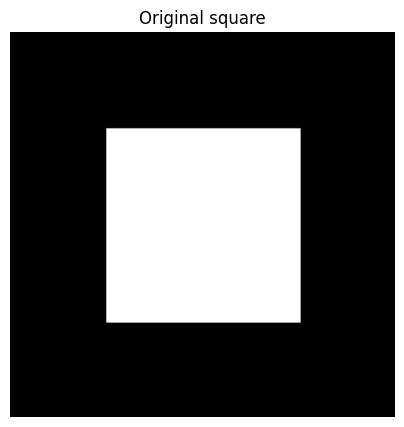

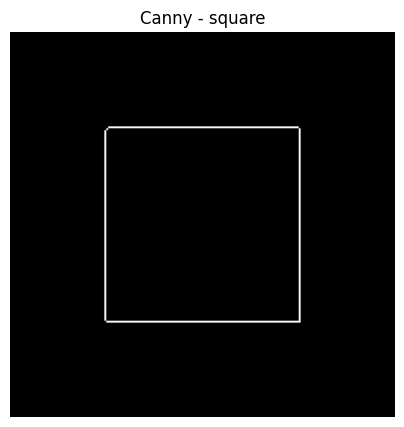

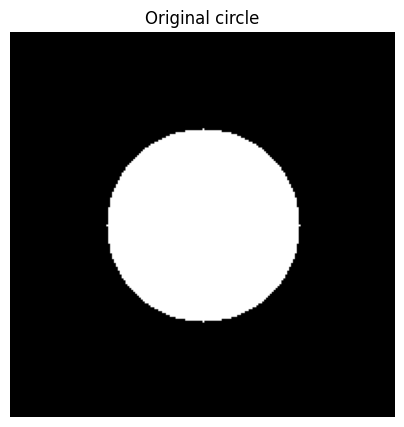

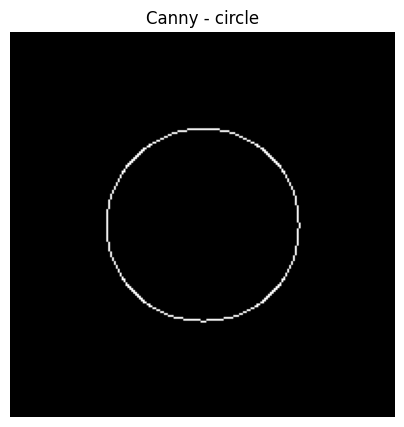

In [2]:
# Basic Canny on square and circle
edges1 = cv2.Canny(img_square, 50, 150)
edges2 = cv2.Canny(img_circle, 50, 150)

show(img_square, "Original square")
show(edges1, "Canny - square")
show(img_circle, "Original circle")
show(edges2, "Canny - circle")

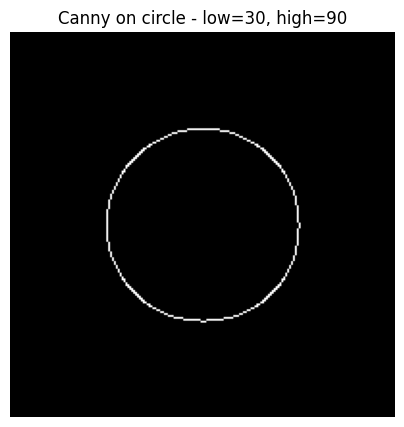

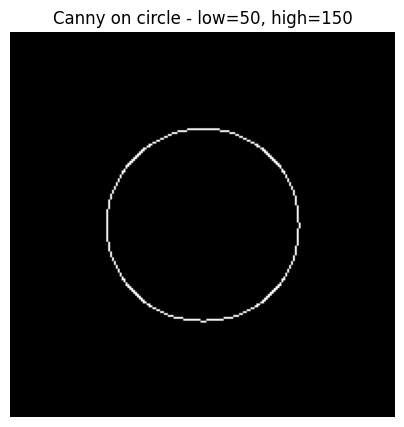

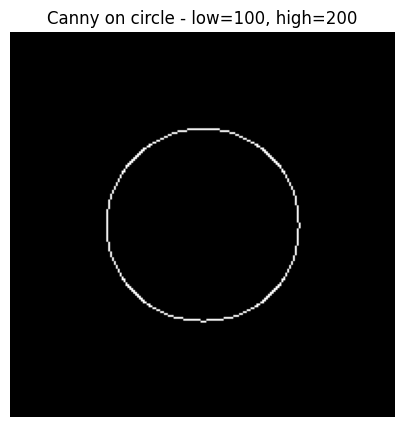

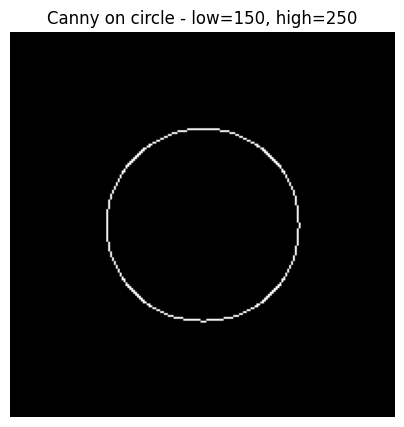

In [3]:
# Test several threshold pairs
pairs = [(30, 90), (50, 150), (100, 200), (150, 250)]

for low, high in pairs:
    edges = cv2.Canny(img_circle, low, high)
    show(edges, f"Canny on circle - low={low}, high={high}")

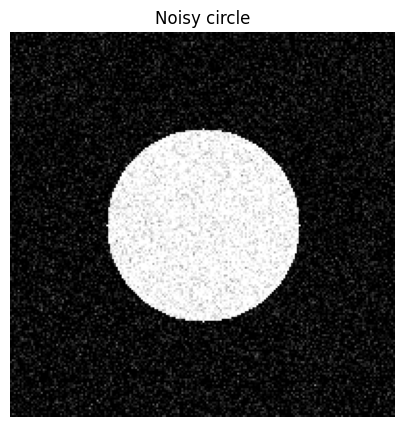

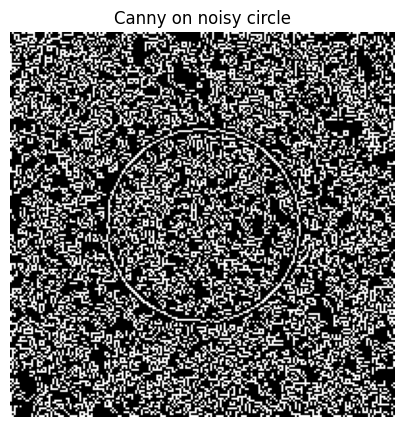

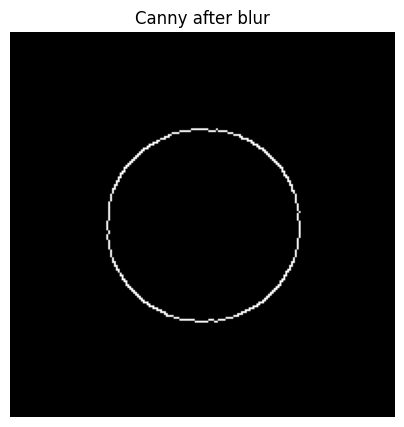

In [4]:
# Compare Canny on noisy image with and without pre-blur
img_circle_noisy = np.clip(
    img_circle + rng.normal(0, 30, img_circle.shape), 0, 255
).astype(np.uint8)

canny_noisy   = cv2.Canny(img_circle_noisy, 50, 150)
canny_blurred = cv2.Canny(cv2.GaussianBlur(img_circle_noisy, (5, 5), 0), 50, 150)

show(img_circle_noisy, "Noisy circle")
show(canny_noisy,      "Canny on noisy circle")
show(canny_blurred,    "Canny after blur")

---
## Basic Tasks

### Task 1 — Apply Canny to the step image

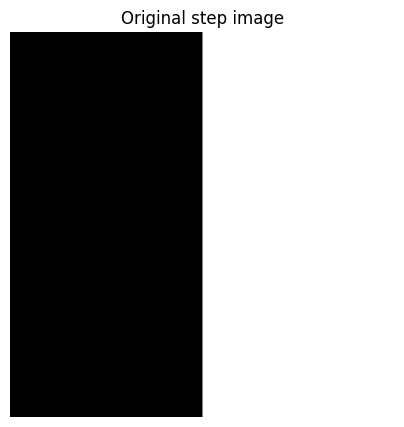

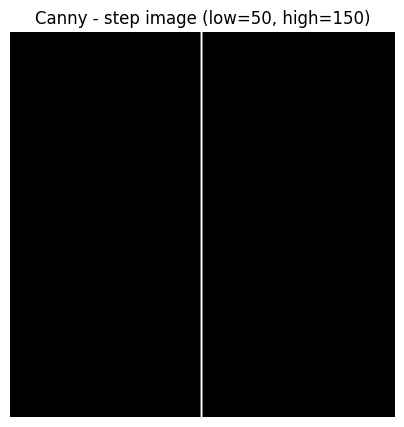

In [5]:
canny_step = cv2.Canny(img_step, 50, 150)

show(img_step,    "Original step image")
show(canny_step,  "Canny - step image (low=50, high=150)")

### Task 2 — Try at least four different threshold pairs

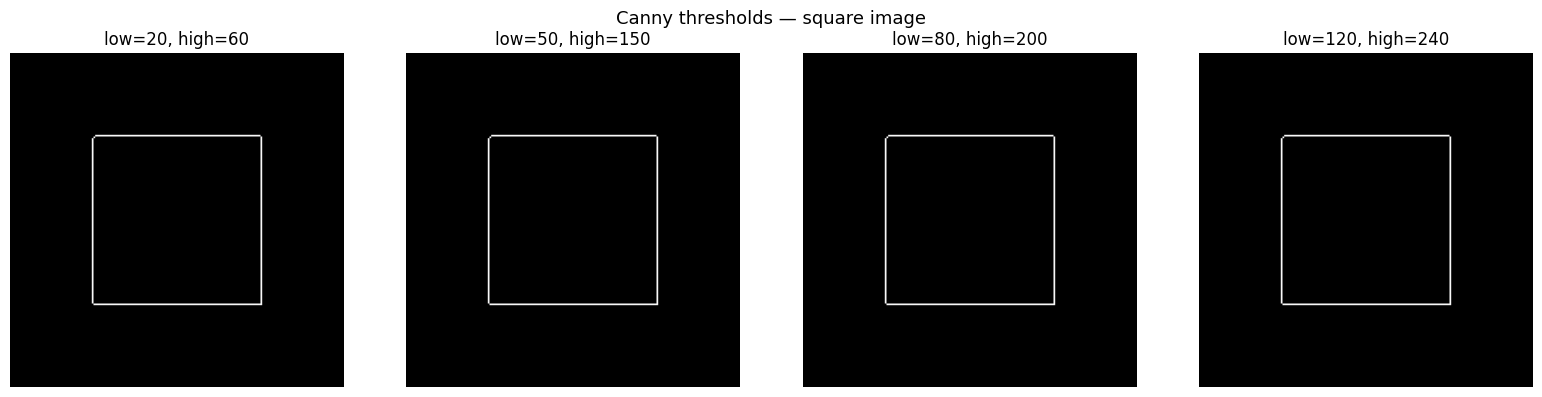

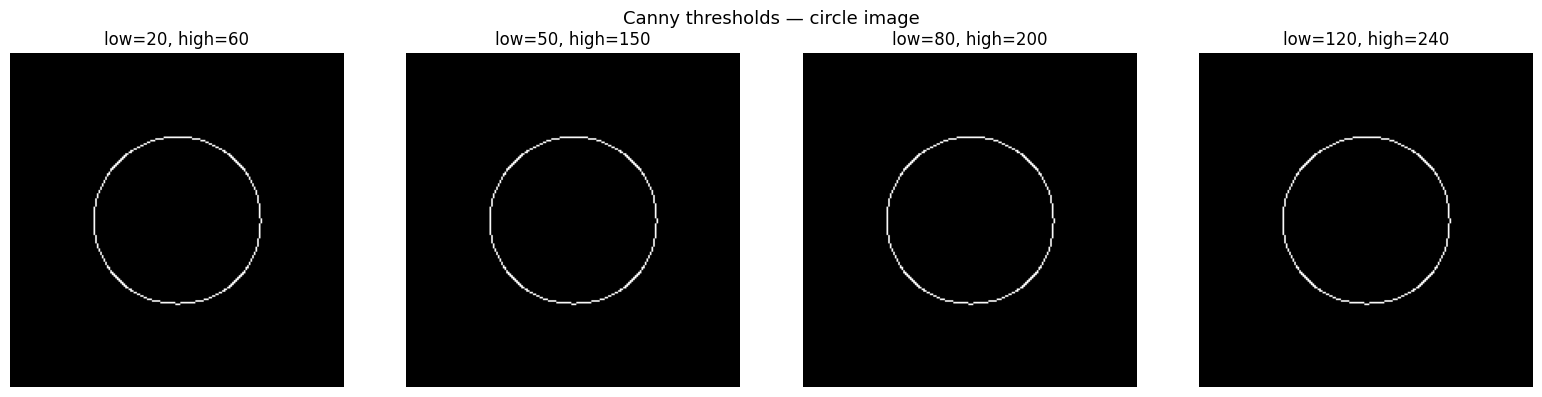

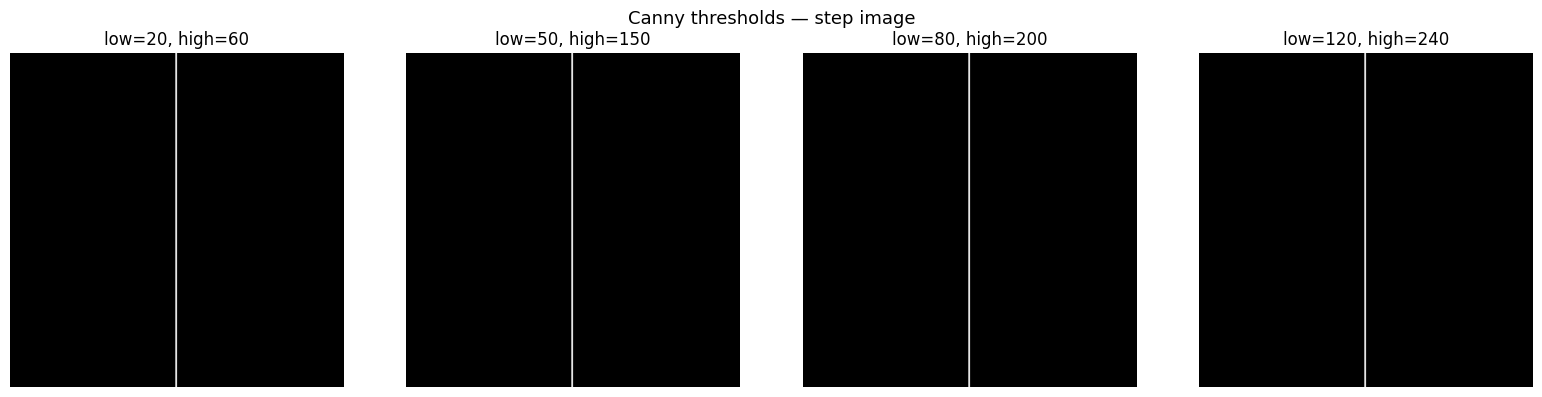

In [6]:
threshold_pairs = [(20, 60), (50, 150), (80, 200), (120, 240)]
images = {
    "square": img_square,
    "circle": img_circle,
    "step":   img_step,
}

for name, img in images.items():
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"Canny thresholds — {name} image", fontsize=13)
    for ax, (low, high) in zip(axes, threshold_pairs):
        result = cv2.Canny(img, low, high)
        ax.imshow(result, cmap="gray")
        ax.set_title(f"low={low}, high={high}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### Task 3 — Decide which threshold pair gives the cleanest result

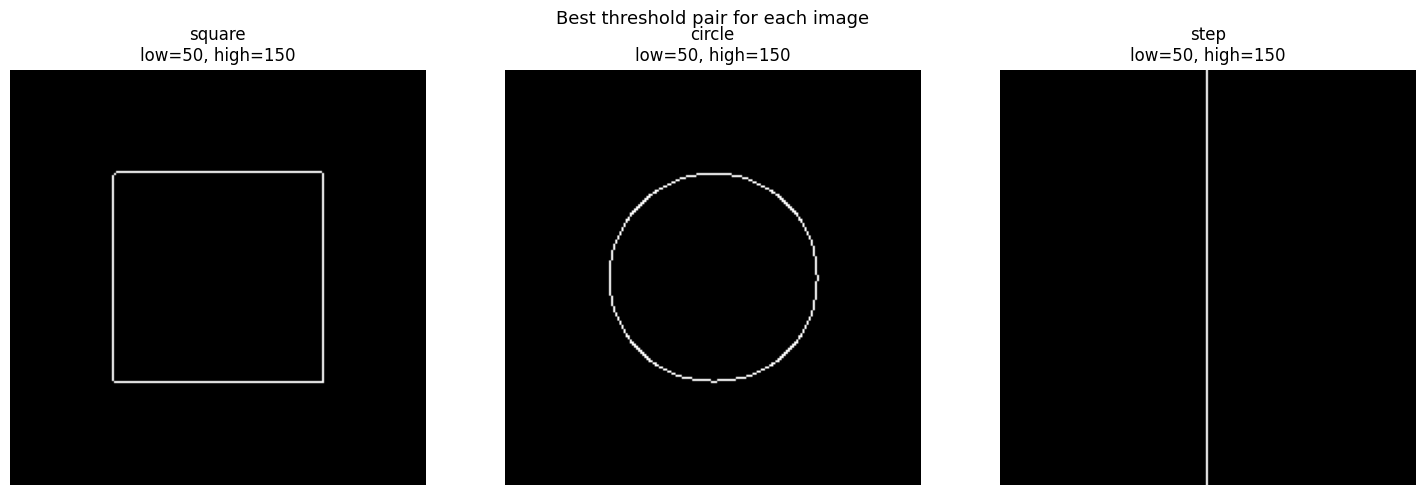


Observation:
- low=50 / high=150 works well for all three clean synthetic images.
- The step image responds strongly at the single vertical boundary.
- Very low thresholds (20/60) produce noisy, fragmented edges on smoother images.
- Very high thresholds (120/240) can drop real edges entirely.



In [7]:
# Best pair selected visually
best = {"square": (50, 150), "circle": (50, 150), "step": (50, 150)}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Best threshold pair for each image", fontsize=13)

for ax, (name, img) in zip(axes, images.items()):
    low, high = best[name]
    result = cv2.Canny(img, low, high)
    ax.imshow(result, cmap="gray")
    ax.set_title(f"{name}\nlow={low}, high={high}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("""
Observation:
- low=50 / high=150 works well for all three clean synthetic images.
- The step image responds strongly at the single vertical boundary.
- Very low thresholds (20/60) produce noisy, fragmented edges on smoother images.
- Very high thresholds (120/240) can drop real edges entirely.
""")

---
## Intermediate Tasks

### Task 4 — Compare Canny with Sobel and Laplacian on the same noisy image

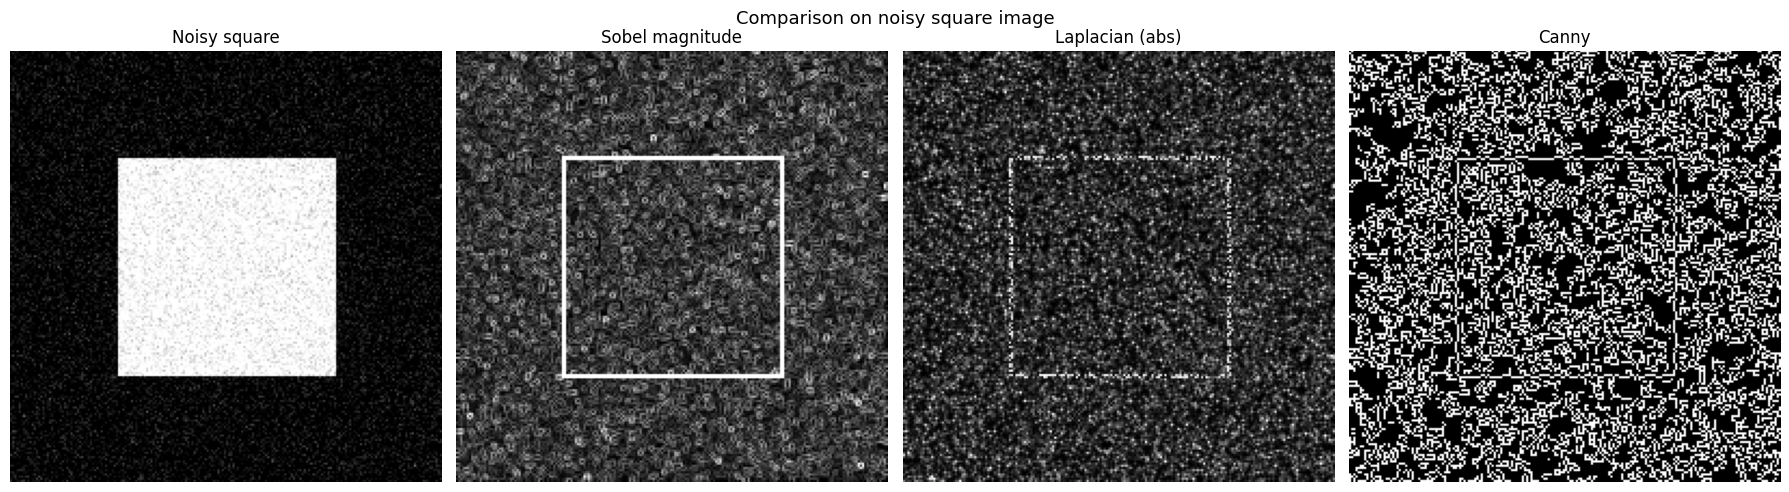


Observation:
- Sobel responds to noise but the square edges are still visible.
- Laplacian is the most noise-sensitive; the output is very noisy.
- Canny suppresses noise well and produces thin, clean edge lines.



In [8]:
rng2 = np.random.default_rng(42)
img_square_noisy = np.clip(
    img_square + rng2.normal(0, 25, img_square.shape), 0, 255
).astype(np.uint8)

# Sobel magnitude
sx = cv2.Sobel(img_square_noisy, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(img_square_noisy, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.clip(np.sqrt(sx**2 + sy**2), 0, 255).astype(np.uint8)

# Laplacian
lap = np.abs(cv2.Laplacian(img_square_noisy, cv2.CV_64F)).astype(np.uint8)

# Canny
canny = cv2.Canny(img_square_noisy, 50, 150)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ["Noisy square", "Sobel magnitude", "Laplacian (abs)", "Canny"]
imgs   = [img_square_noisy, sobel_mag, lap, canny]

for ax, im, t in zip(axes, imgs, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(t)
    ax.axis("off")

plt.suptitle("Comparison on noisy square image", fontsize=13)
plt.tight_layout()
plt.show()

print("""
Observation:
- Sobel responds to noise but the square edges are still visible.
- Laplacian is the most noise-sensitive; the output is very noisy.
- Canny suppresses noise well and produces thin, clean edge lines.
""")

### Task 5 — Explain why Canny usually produces thinner edges

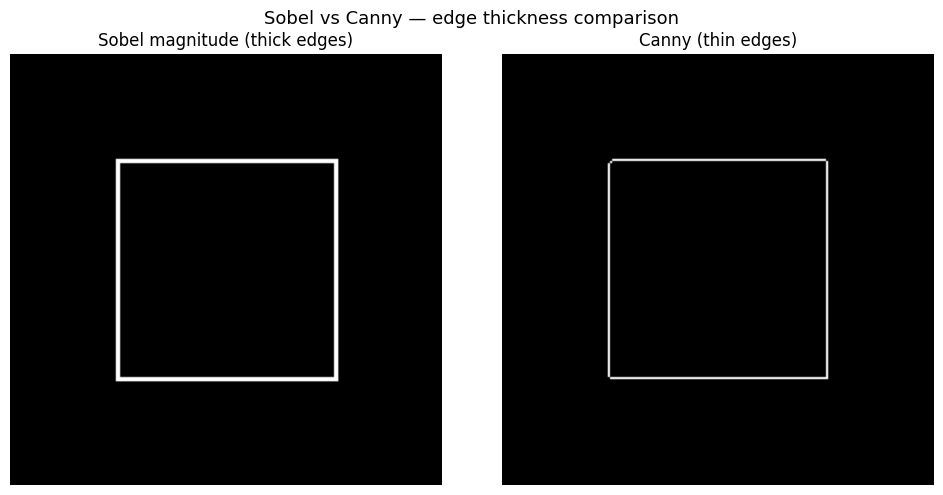


Why Canny produces thinner edges:

Canny includes a step called Non-Maximum Suppression (NMS).
After computing the gradient, NMS keeps only the local maximum
pixel along the gradient direction and suppresses all others.
This ensures that each edge is only one pixel wide.

Sobel simply computes the gradient magnitude, which can produce
wide ridges because many neighbouring pixels share a high response.
There is no thinning step in Sobel alone.



In [9]:
# Visual demonstration: Sobel vs Canny edge thickness
sobel_x_clean = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_clean = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag_clean = np.clip(np.sqrt(sobel_x_clean**2 + sobel_y_clean**2), 0, 255).astype(np.uint8)
canny_clean = cv2.Canny(img_square, 50, 150)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sobel_mag_clean, cmap="gray")
axes[0].set_title("Sobel magnitude (thick edges)")
axes[0].axis("off")

axes[1].imshow(canny_clean, cmap="gray")
axes[1].set_title("Canny (thin edges)")
axes[1].axis("off")

plt.suptitle("Sobel vs Canny — edge thickness comparison", fontsize=13)
plt.tight_layout()
plt.show()

print("""
Why Canny produces thinner edges:

Canny includes a step called Non-Maximum Suppression (NMS).
After computing the gradient, NMS keeps only the local maximum
pixel along the gradient direction and suppresses all others.
This ensures that each edge is only one pixel wide.

Sobel simply computes the gradient magnitude, which can produce
wide ridges because many neighbouring pixels share a high response.
There is no thinning step in Sobel alone.
""")

### Task 6 — Effect of Gaussian blur before Canny with different kernel sizes

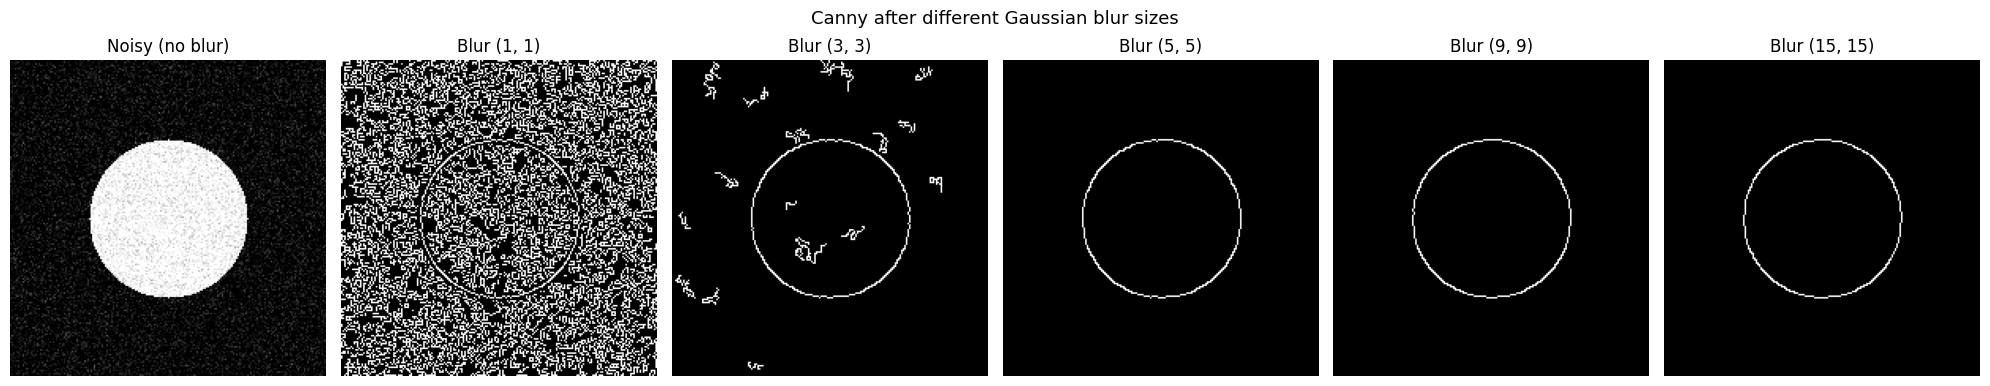


Observation:
- No blur: many false edges from noise.
- (3,3):   noise reduced slightly, some false edges remain.
- (5,5):   good balance — circle edge is clean and complete.
- (9,9):   edge is still clean but slightly thickened/shifted.
- (15,15): over-smoothed; small details start to disappear.

Best balance for this noisy circle: blur kernel (5,5).



In [10]:
rng3 = np.random.default_rng(7)
img_noisy_t6 = np.clip(
    img_circle + rng3.normal(0, 30, img_circle.shape), 0, 255
).astype(np.uint8)

kernel_sizes = [(1, 1), (3, 3), (5, 5), (9, 9), (15, 15)]

fig, axes = plt.subplots(1, len(kernel_sizes) + 1, figsize=(20, 4))
axes[0].imshow(img_noisy_t6, cmap="gray")
axes[0].set_title("Noisy (no blur)")
axes[0].axis("off")
# k=(1,1) effectively means no blur
for ax, k in zip(axes[1:], kernel_sizes):
    if k == (1, 1):
        blurred = img_noisy_t6
    else:
        blurred = cv2.GaussianBlur(img_noisy_t6, k, 0)
    result = cv2.Canny(blurred, 50, 150)
    ax.imshow(result, cmap="gray")
    ax.set_title(f"Blur {k}")
    ax.axis("off")

plt.suptitle("Canny after different Gaussian blur sizes", fontsize=13)
plt.tight_layout()
plt.show()

print("""
Observation:
- No blur: many false edges from noise.
- (3,3):   noise reduced slightly, some false edges remain.
- (5,5):   good balance — circle edge is clean and complete.
- (9,9):   edge is still clean but slightly thickened/shifted.
- (15,15): over-smoothed; small details start to disappear.

Best balance for this noisy circle: blur kernel (5,5).
""")

---
## Challenging Tasks

### Task 7 — Mini experiment: clean, noisy, and blurred images

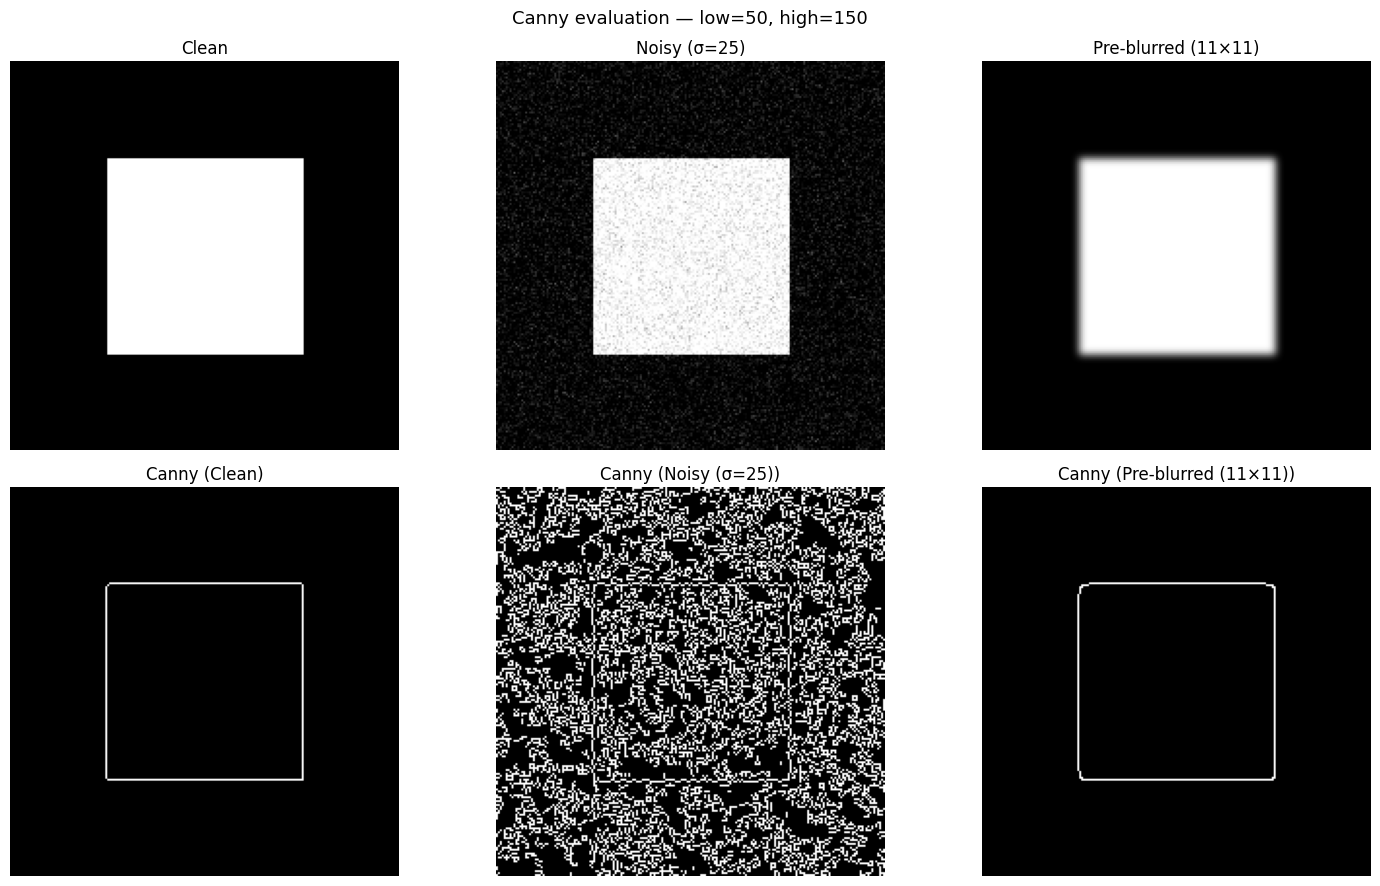

In [11]:
rng4 = np.random.default_rng(99)

# Prepare three variants
img_clean   = img_square.copy()
img_noisy_t7 = np.clip(
    img_square + rng4.normal(0, 25, img_square.shape), 0, 255
).astype(np.uint8)
img_blurred_t7 = cv2.GaussianBlur(img_square, (11, 11), 0)

variants = [
    (img_clean,      "Clean"),
    (img_noisy_t7,   "Noisy (σ=25)"),
    (img_blurred_t7, "Pre-blurred (11×11)"),
]

low, high = 50, 150

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (img_v, label) in enumerate(variants):
    result = cv2.Canny(img_v, low, high)
    axes[0, col].imshow(img_v, cmap="gray")
    axes[0, col].set_title(label)
    axes[0, col].axis("off")
    axes[1, col].imshow(result, cmap="gray")
    axes[1, col].set_title(f"Canny ({label})")
    axes[1, col].axis("off")

plt.suptitle(f"Canny evaluation — low={low}, high={high}", fontsize=13)
plt.tight_layout()
plt.show()

**Summary of observations:**

| Image variant | Canny result |
|---|---|
| Clean | Perfect thin rectangle outline; no false edges |
| Noisy (σ=25) | Rectangle outline still visible but extra edge fragments appear |
| Pre-blurred (11×11) | Very clean rectangle outline; some corner sharpness lost |

### Task 8 — `run_canny` function with multiple parameter tests

In [ ]:
def run_canny(image, low, high, blur=False, blur_ksize=(5, 5)):
    """
    Apply Canny edge detection.

    Parameters
    ----------
    image      : uint8 grayscale image
    low        : lower hysteresis threshold
    high       : upper hysteresis threshold
    blur       : if True, apply Gaussian blur before Canny
    blur_ksize : kernel size for Gaussian blur

    Returns
    -------
    edges : binary edge map (uint8)
    """
    processed = cv2.GaussianBlur(image, blur_ksize, 0) if blur else image
    return cv2.Canny(processed, low, high)


# Test with multiple parameter combinations
test_cases = [
    (img_square, 30,  90,  False, "Square — 30/90,  no blur"),
    (img_square, 50,  150, False, "Square — 50/150, no blur"),
    (img_square, 50,  150, True,  "Square — 50/150, blur(5,5)"),
    (img_circle, 50,  150, False, "Circle — 50/150, no blur"),
    (img_circle, 100, 200, False, "Circle — 100/200, no blur"),
    (img_step,   50,  150, False, "Step   — 50/150, no blur"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (img_t, low_t, high_t, do_blur, label) in zip(axes.flat, test_cases):
    result = run_canny(img_t, low_t, high_t, blur=do_blur)
    ax.imshow(result, cmap="gray")
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.suptitle("run_canny — parameter exploration", fontsize=13)
plt.tight_layout()
plt.show()

### Task 9 — Find a threshold pair that works well for the square but poorly for the circle

In [ ]:
# A high-threshold pair: good for square (high-contrast straight edges)
# but poor for circle (curved edges have slightly weaker gradient)
low_test,  high_test  = 130, 255
low_good,  high_good  = 50,  150

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

cases = [
    (img_square, low_good,  high_good,  "Square — 50/150 (good)"),
    (img_circle, low_good,  high_good,  "Circle — 50/150 (good)"),
    (img_square, low_test,  high_test,  "Square — 130/255 (still ok)"),
    (img_circle, low_test,  high_test,  "Circle — 130/255 (edge lost)"),
]

for ax, (img_t, low_t, high_t, label) in zip(axes.flat, cases):
    result = cv2.Canny(img_t, low_t, high_t)
    ax.imshow(result, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.suptitle("Same threshold — different behaviour on square vs circle", fontsize=13)
plt.tight_layout()
plt.show()

print("""
Explanation:
The square has a perfectly sharp, high-contrast edge — the pixel
intensity jumps from 0 to 255 in one step, creating a very large
gradient. A high threshold (130/255) still detects it.

The circle is rendered by OpenCV with anti-aliasing, so its boundary
transitions more gradually. This lowers the maximum gradient magnitude
along parts of the curved edge. A threshold of 130/255 is too strict
and misses portions of the circle.

This shows that one threshold setting is NOT universally optimal —
it must be tuned to the content of each image.
""")

### Task 10 — Apply Canny to a real image and tune thresholds manually

In [ ]:
import os

# Load the real image provided in the lab folder
real_img_path = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                              "team2.jpg")
real_bgr = cv2.imread(real_img_path)

if real_bgr is None:
    # Fallback: try relative path
    real_bgr = cv2.imread("team2.jpg")

if real_bgr is None:
    print("Image not found — using a synthetic gradient image as substitute.")
    real_gray = np.zeros((200, 400), dtype=np.uint8)
    cv2.putText(real_gray, "TEAM2", (60, 130),
                cv2.FONT_HERSHEY_SIMPLEX, 3, 200, 4)
else:
    real_gray = cv2.cvtColor(real_bgr, cv2.COLOR_BGR2GRAY)

show(real_gray, "Real image (grayscale)", size=(8, 6))

# Try several threshold pairs
threshold_pairs_real = [(30, 90), (50, 150), (80, 200), (120, 240)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Canny on real image — threshold tuning", fontsize=13)
for ax, (low_r, high_r) in zip(axes, threshold_pairs_real):
    result = cv2.Canny(real_gray, low_r, high_r)
    ax.imshow(result, cmap="gray")
    ax.set_title(f"low={low_r}, high={high_r}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Final best choice with blur
best_low, best_high = 50, 150
real_blurred = cv2.GaussianBlur(real_gray, (5, 5), 0)
final_edges = cv2.Canny(real_blurred, best_low, best_high)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(real_gray, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[0].axis("off")
axes[1].imshow(final_edges, cmap="gray")
axes[1].set_title(f"Final Canny — low={best_low}, high={best_high}, blur=(5,5)")
axes[1].axis("off")
plt.suptitle("Best Canny result on real image", fontsize=13)
plt.tight_layout()
plt.show()

print(f"""
Final choice: low={best_low}, high={best_high}, Gaussian blur (5,5)

Reasoning:
- (30/90): too many weak/noisy edges detected across the whole image.
- (50/150): good balance — main structural edges preserved, most noise rejected.
- (80/200): slightly too strict, some finer edges start to disappear.
- (120/240): only the strongest transitions remain; too much detail lost.

Adding a (5,5) Gaussian blur before Canny smoothed out sensor noise
while preserving the important structural edges in the image.
""")